# WARNING - THIS CODE IS MID (I HAVE NOT REFACTORED IT)

## Coupled Permanent Magnets Simulation
Documentation: https://docs.google.com/presentation/d/1INlCZmiFLztyq61BgA-tvESFtgUuOYCLFEUQNp9QsF8/edit?usp=drive_link

## About
The following script generates a FEMM model, solves it, conducts additional calculations, and extracts data for axisymmetric magnetostatic problems.

## Prerequisites
- Python 3.9 (https://www.python.org/downloads/release/python-390/). I suggest the Miniconda version (https://docs.conda.io/projects/miniconda/en/latest/miniconda-other-installer-links.html.
- Jupyter Notebooks

## Setup
1. Download FEMM (https://www.femm.info/wiki/HomePage)
2. pip install pyfemm
* If you have MacOS or Linux refer to the manual (https://www.femm.info/wiki/pyFEMM/manual.pdf)

## Resources
- FEMM Official Documentation (https://www.femm.info/wiki/Documentation/)

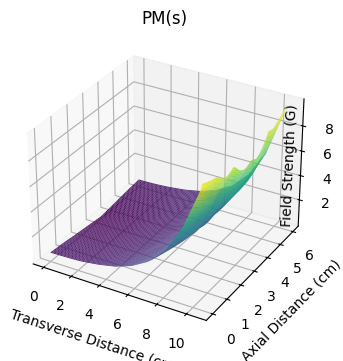

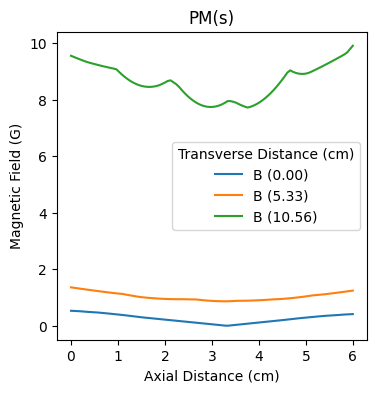

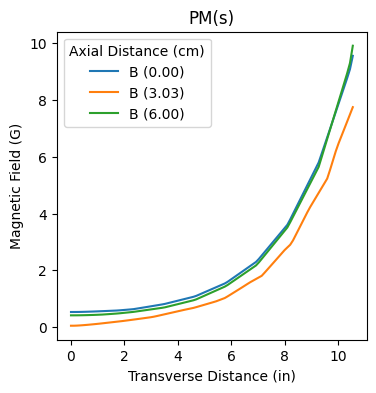

Electrode Width/2: 10.56 cm
Electrode Area: 350.00 cm^2
PM Outer Radius: 18.56 cm
Distance between PMs: 6.00 cm
The maximum transverse gradient is 2.83e-02 G/cm at (10.56, 0.00)
The maximum axial gradient is 7.41e-04 G/cm at (0.0, 1.27)


'\nclose\n'

In [1]:
""" 
Kostubh Agarwal
kagarwal@formenergy.com
"""
import femm
import matplotlib.pyplot as plt
import numpy as np

"""
specs
"""
elec_a = 350 #Area of WE (cm^2)
elec_t = 0.05 #electrode thickness (cm)
elec_d = 3 #distance from EM (cm)
elec_r = np.sqrt(elec_a / np.pi) #electrode radius (cm)

mag_off = 8 #elec&pmag offset (cm)
pmag_r = elec_r+mag_off #OD of pmag (cm)
pmag_t = 6 #thickness of pmag (cm)
sep = 6 #seperation of pmag's (cm)

par_r = 0.01 #particle radius (cm)
par_d = 0.5 #distance from surface of magnet
par_z = pmag_t / 2 + par_d #particle position (cm)

"""
simulation parameters
"""
label_tol = 1e-2 #ignore
precision = 1e-9 #solver precision

"""
data analysis
"""
num = 100 #discretization of grid (data visualtization only)
m1 = int(num/2) #@elec_r/2
m2 = int(num-1) #@elec_r
intervals = [0, m1, m2] #analysis intervals

"""
initialization
"""
femm.openfemm();
femm.newdocument(0)

"""
problem definition

magnetostatic; units of measure; axisymmetric; 
precision for the linear solver; a placeholder for 
the depth dimension; angle constraint of 30 degrees;
"""
femm.mi_probdef(0, 'centimeters', 'axi', precision, 0, 30); 

"""
setup - materials
"""
bdata = [0.000000, 0.056855, 0.070679, 0.088178, 0.090246, 0.092263, 0.224499, 0.257443, 0.266530, 0.288314, 0.333679, 0.352664, 0.404646, 0.410247, 0.433867, 0.470015, 0.490399, 0.494892, 0.508558, 0.546380, 0.586685, 0.590509, 0.603583, 0.613213, 0.625268, 0.632070, 0.643027, 0.682933,
0.694518, 0.737378, 0.767764, 0.883664, 0.981222, 1.009461]
hdata = [0.000000, 63.557963, 69.056222, 75.810815, 76.600889, 77.399185, 141.192593, 166.668519, 175.539259, 205.092222, 301.095185, 366.736296, 850.455185, 943.526667, 1687.981481, 3180.525926, 4166.196296, 4434.014815, 5127.622222, 7767.114815, 13328.370370, 14185.407407, 17460.481481,
19984.296296, 26455.962963, 29658.814815, 36131.629630, 63324.185185, 72483.592593, 104274.074074, 128363.703704, 220358.148148, 297860.370370, 320300.000000]
for idx in range(len(bdata)):
    femm.mi_addbhpoint('Pure nickel annealed', bdata[idx], hdata[idx])  

femm.mi_addmaterial('Iron', 14872, 14872, 0, 0, 0, 1, 0, 0, 0, 0, 0);
bdata = [0.000000, 0.227065, 0.454130, 0.681195, 0.908260, 1.135330, 1.362390, 1.589350, 1.812360, 2.010040, 2.133160, 2.199990, 2.254790, 2.299930, 2.342510, 2.378760, 2.415010, 2.451260, 2.487500, 2.523750, 2.560000]
hdata = [0.000000, 13.898400, 27.796700, 42.397400, 61.415700, 82.382400, 144.669000, 897.760000, 4581.740000, 17736.200000, 41339.300000, 68321.800000, 95685.500000, 123355.000000, 151083.000000, 178954.000000, 206825.000000, 234696.000000, 262568.000000, 290439.000000, 318310.000000]
for idx in range(len(bdata)):
    femm.mi_addbhpoint('Iron', bdata[idx], hdata[idx])

femm.mi_getmaterial('Cast Alnico 5 (LNG40)') #pmag material

"""
setup - physical
"""
femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0);
femm.mi_addblocklabel(pmag_r+label_tol, 0);
femm.mi_selectlabel(pmag_r+label_tol, 0);
femm.mi_setblockprop('Air', 1, 0, '<None>', 0, 0, 0);
femm.mi_clearselected()

femm.mi_drawrectangle(0, sep/2, pmag_r, sep/2+pmag_t); #top pmag
femm.mi_addblocklabel(label_tol, sep/2+label_tol);
femm.mi_selectlabel(label_tol, sep/2+label_tol);
femm.mi_setblockprop('Cast Alnico 5 (LNG40)', 0, 0, '<None>', 90, 0, 0); #magnetization directon
femm.mi_clearselected()

femm.mi_drawrectangle(0, -sep/2, pmag_r, -sep/2-pmag_t); #bottom pmag
femm.mi_addblocklabel(label_tol, -sep/2-label_tol);
femm.mi_selectlabel(label_tol, -sep/2-label_tol);
femm.mi_setblockprop('Cast Alnico 5 (LNG40)', 0, 0, '<None>', -90, 0, 0); #magnetization directon
femm.mi_clearselected()

# #additional
# femm.mi_drawrectangle(0, elec_d-sep/2, elec_r, elec_d+elec_t-sep/2); #working electrode
# femm.mi_addmaterial('Pure nickel annealed')
# femm.mi_addblocklabel(label_tol, elec_d+elec_t/2-sep/2);
# femm.mi_selectlabel(label_tol, elec_d+elec_t/2-sep/2);
# femm.mi_setblockprop('Pure nickel annealed', 1, 0, '<None>', 0, 0, 0);
# femm.mi_clearselected()

# femm.mi_drawrectangle(0, - par_r + par_z - sep, par_r, par_r + par_z - sep); #particle
# femm.mi_addblocklabel(par_r / 2, par_r + par_z - sep - label_tol);
# femm.mi_selectlabel(par_r / 2, par_r + par_z - sep - label_tol);
# femm.mi_setblockprop('Iron', 1, 0, '<None>', 0, 2, 0);
# femm.mi_clearselected()

"""
dirichlet BC 
"""
femm.mi_makeABC(7, pmag_r*2, 0, 0, 0)  
    
"""
save file
"""
femm.mi_zoomnatural()
femm.mi_saveas('coupled_permanent_mag_sim.fem');

"""
mesh and solve
"""
femm.mi_analyze()
femm.mi_loadsolution()

"""
force
"""
# femm.mo_groupselectblock(2)
# par_force=femm.mo_blockintegral(19)

"""
plots
"""
x = np.linspace(0, elec_r, num) #initiliazing domain
y = np.linspace(0, sep, num) #initializing range
Z = np.zeros((num, num)) #initilizing flux array
for a in range(0, num):
    for b in range(0, num):
        s, t = femm.mo_getb(x[a], -sep/2+y[b])
        Z[a, b] = (np.sqrt(s ** 2 + t ** 2)) / 1e-4 #tesla --> gauss        
ax = plt.figure(figsize=(4,4)).add_subplot(111, projection='3d') #3d plot
Y, X = np.meshgrid(y, x)
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis', edgecolor='none')
ax.set_title('PM(s)')
ax.set_xlabel("Transverse Distance (cm)")
ax.set_ylabel("Axial Distance (cm)")
ax.set_zlabel("Field Strength (G)")
ax.zaxis.labelpad = -26

plt.figure(figsize=(4,4))  # axial flux variation
for ix in intervals:
    x_data = y  
    y_data = Z[ix, :]
    label = f'B ({x[ix]:.2f})'
    plt.plot(x_data, y_data, label=label)
plt.title('PM(s)')
plt.xlabel('Axial Distance (cm)')
plt.ylabel('Magnetic Field (G)')
legend = plt.legend()
legend.set_title('Transverse Distance (cm)')
plt.show()

plt.figure(figsize=(4,4))  # radial flux variation
for iy in intervals:
    x_data = x
    y_data = Z[:, iy]
    label = f'B ({y[iy]:.2f})'
    plt.plot(x_data, y_data, label=label)
plt.title('PM(s)')
plt.xlabel('Transverse Distance (in)')
plt.ylabel('Magnetic Field (G)')
legend = plt.legend()
legend.set_title('Axial Distance (cm)')
plt.show()

"""
max gradient calcs
"""
loc_r = 0 
loc_z = 0

fr = Z[:, loc_r]
fz = Z[loc_z, :]

dr = np.abs(np.diff(fr))
m_dr = np.max(dr) * (sep / num)
m_dr_i = np.argmax(dr) + 1

dz = np.abs(np.diff(fz))  
m_dz = np.max(dz) * (sep / num)
m_dz_i = np.argmax(dz) + 1

"""
output
"""
print(f"Electrode Width/2: {elec_r:.2f} cm")
print(f"Electrode Area: {elec_a:.2f} cm^2")
print(f"PM Outer Radius: {pmag_r:.2f} cm")
print(f"Distance between PMs: {sep:.2f} cm")
# print(f"Force on particle (rectangle with width/2 & height: {par_r:.2e}) at {par_d:.2f} cm away: {par_force:.2e} N")
print(f"The maximum transverse gradient is {m_dr:.2e} G/cm at ({x[m_dr_i]:.2f}, {y[loc_r]:.2f})")
print(f"The maximum axial gradient is {m_dz:.2e} G/cm at ({x[loc_z]}, {y[m_dz_i]:.2f})")

"""
close
"""
# femm.closefemm()
